# Caracteristicas musicales


A lo largo de este documento, se analizaran las relaciones existentes entre las dirferentes caracteristicas musicales que posee el dataset, asi mismo, se intentara dar una respuesta a las preguntas:

1. ¿Existen grupos naturales de canciones con características similares?
2. ¿Qué características presentan las correlaciones más fuertes?
3. ¿Las canciones con alta danceability también suelen tener alta energy?
4 ¿Existe relación entre valence (positividad emocional) y popularidad?
5. ¿Qué variables explican mejor la variabilidad musical del conjunto de datos?
6. ¿Es posible identificar géneros o estilos únicamente a partir de características acústicas?

<hr />

### 0. Analisis general del comportamiento de variables
Para responder a esta pregunta, se analizaran las diversas distribuciones de las caracteristicas musicales con el fin de poder entender su coomportamiento y agruparlas entre si.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


datos = pd.read_csv('../dataset/main_dataset.csv', usecols=['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','valence','tempo','duration_ms','time_signature','liveness'])


In [2]:
datos.head()
datos.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,2.779380e+05,277938.000000
mean,0.552583,0.556866,5.236873,-10.363654,0.637383,0.087913,0.386583,0.255044,0.189217,0.449602,119.196002,2.324961e+05,3.877793
std,0.188905,0.279681,3.556635,6.672049,0.480756,0.112500,0.364504,0.373745,0.163596,0.267471,30.462256,1.171830e+05,0.469444
min,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.706000e+03,0.000000
25%,0.431000,0.342000,2.000000,-12.747000,0.000000,0.035900,0.033800,0.000000,0.096200,0.220000,95.072250,1.720130e+05,4.000000
50%,0.571000,0.591000,5.000000,-8.397000,1.000000,0.047100,0.262000,0.001090,0.121000,0.434000,119.940000,2.131055e+05,4.000000
75%,0.693000,0.792000,8.000000,-5.842000,1.000000,0.082200,0.754000,0.645000,0.227000,0.665000,138.869750,2.648660e+05,4.000000
max,0.989000,1.000000,11.000000,4.882000,1.000000,0.965000,0.996000,1.000000,1.000000,1.000000,244.947000,3.919895e+06,5.000000


### Exploracion de datos faltantes del dataset

In [3]:
informe = {
    'faltantes':datos.isna().sum(),
    'Porcentaje':datos.isna().mean()
}
print(informe)

{'faltantes': danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64, 'Porcentaje': danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
duration_ms         0.0
time_signature      0.0
dtype: float64}


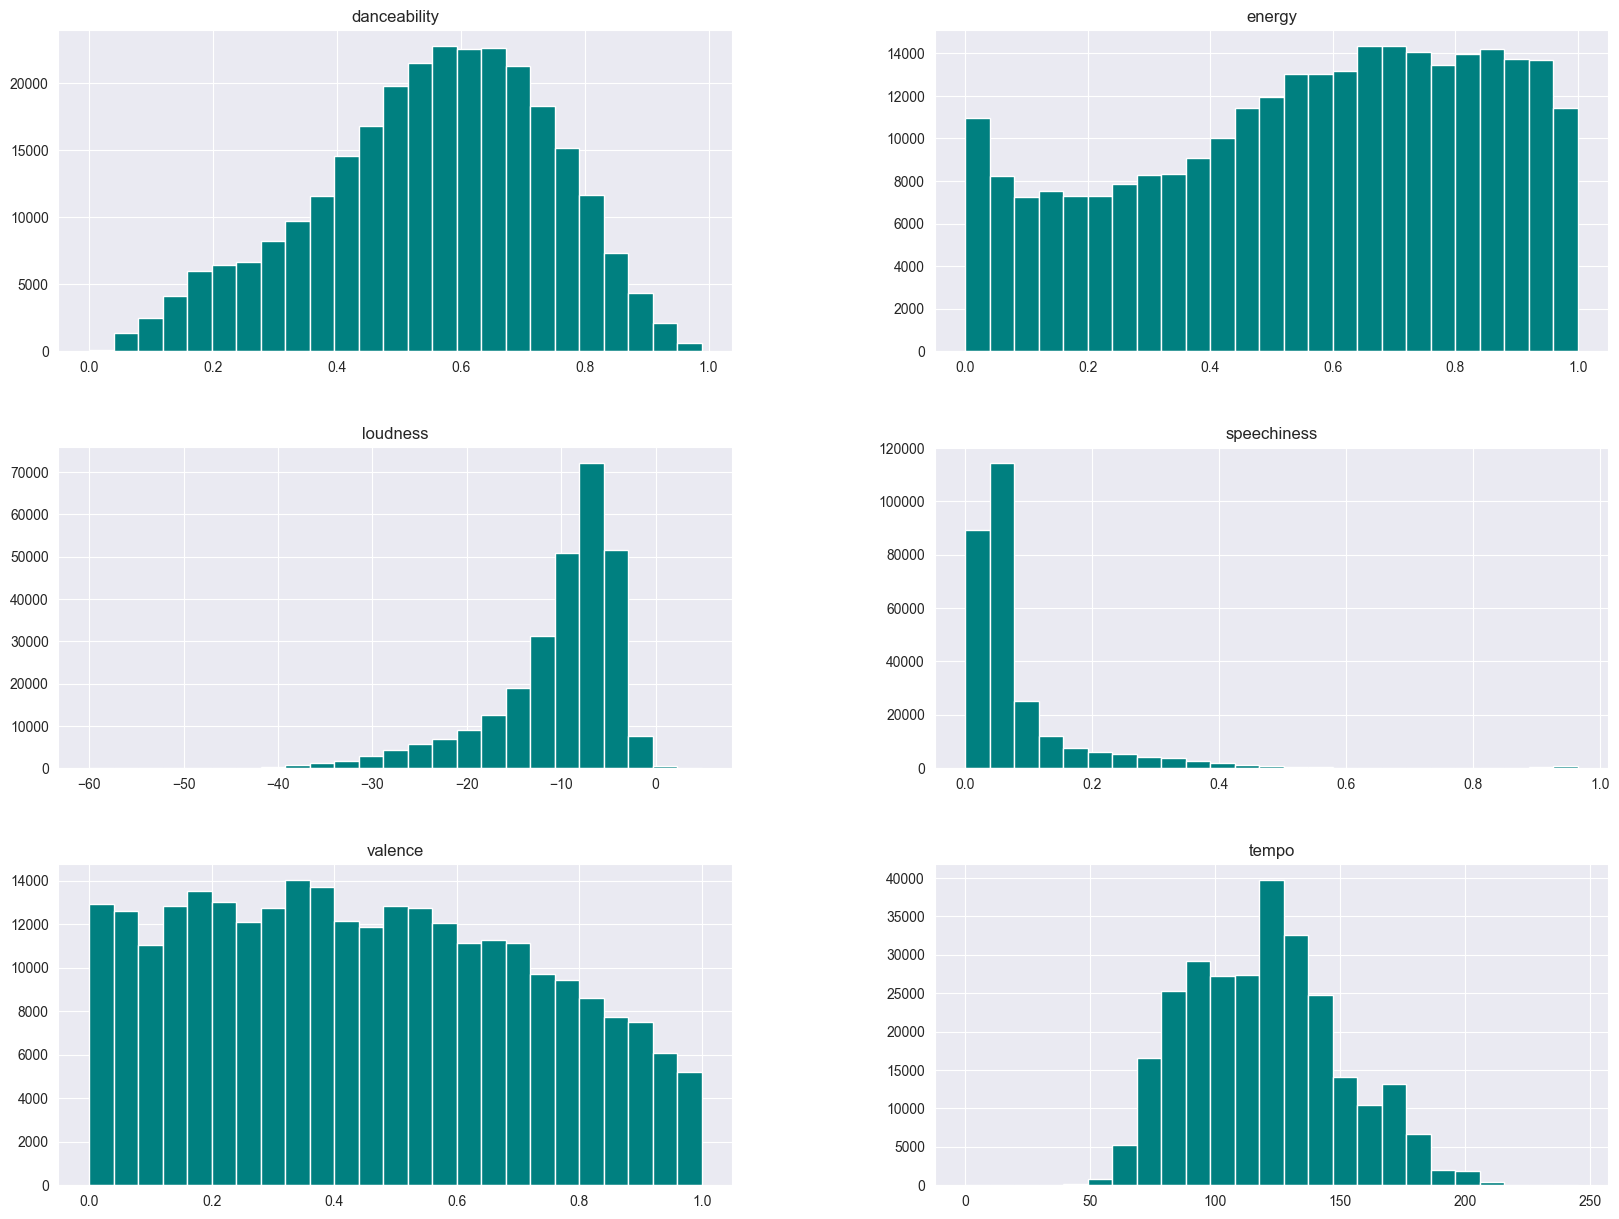

In [4]:
sns.set_style('darkgrid')
columnas_de_interes = datos[['danceability','energy','loudness','speechiness','valence','tempo']]
columnas_de_interes.hist(figsize=(20,15), color='teal', bins=25)

plt.show()

array([[<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'duration_ms'}>],
       [<Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >]],
      dtype=object)

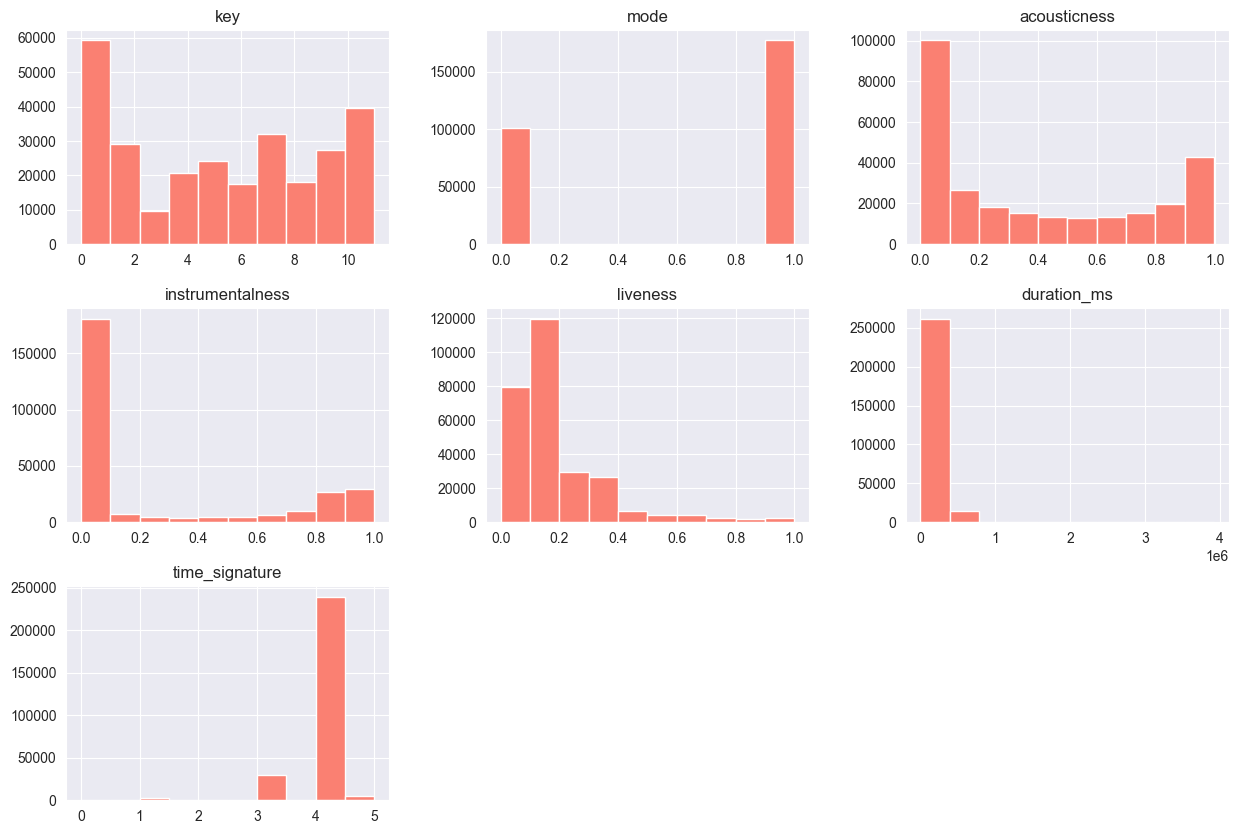

In [5]:
otras_columnas = datos[['key', 'mode', 'acousticness', 'instrumentalness', 'liveness', 'duration_ms', 'time_signature']]
otras_columnas.hist(figsize = (15,10), color='salmon')

## Para danceability)
Debido a que aparente mente presenta una distribucion normal, tomaremos una muestra de 500 datos y aplicaremos la prueba de kolmogorov-Srmirnov para tener resolapdo estadistico de si una distribucion es normal o no.




In [6]:
import scipy.stats as stats
import numpy as np

muestra =  (
    columnas_de_interes['danceability']
    .sample(n=800, random_state=777)
    )

media_muestra = np.mean(muestra)
ds_muestra = np.std(muestra)

ks_stat, ks_p_value = stats.kstest(muestra, 'norm', args=(media_muestra, ds_muestra))

print(f"Estadistico KS: {ks_stat:.4f}")
print(f"Valor p: {ks_p_value:.4f}")
if ks_p_value > 0.05:
    print("Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).")
else:
    print(
        "Resultado: Los datos NO siguen una distribución normal (p <= 0.05)."
    )


Estadistico KS: 0.0453
Valor p: 0.0727
Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).


La observación de que el atributo de *danceability* en Spotify sigue una distribución normal permite inferir que
la mayor parte de las canciones posee un nivel moderado, lo que sugiere que, en general, las personas
pueden mover la cabeza o los pies al escucharlas. Sin embargo, la cola derecha de la distribución indica que solo
una pequeña proporción de canciones alcanza un grado de danceability alto, lo que permitiría a los usuarios
comprometerse plenamente con la danza. Este patrón refuerza la idea de que, aunque la mayoría de las canciones
están diseñadas para ser disfrutadas de manera dinámica, la experiencia de "bailar sin reservas" es una rareza
estadística. Dicho de otra forma, **pocas canciones dentro del catalogo se pueden bailar de forma tradicional**.

### Para speechiness)


Estadistico KS: 0.2548
Valor p: 0.0000
Resultado: Los datos NO siguen una distribucion exponencial (p <= 0.05).


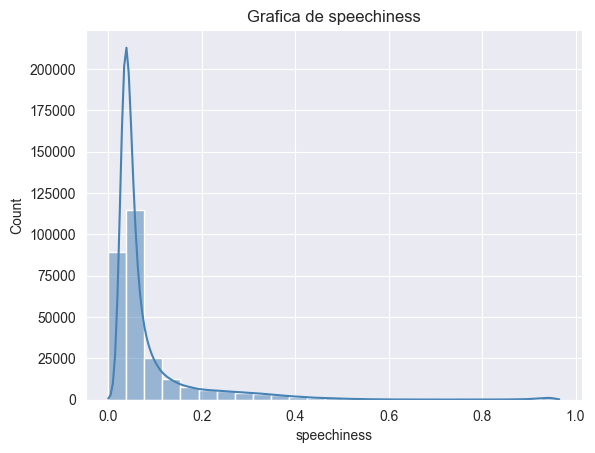

In [7]:
sns.histplot(datos, x='speechiness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de speechiness')

speechines_muestra = datos['speechiness'].sample(n=800, random_state=777)

loc = 0
escala = np.mean(speechines_muestra)

kse_stat, kse_p_value = stats.kstest(speechines_muestra, 'expon', args=(loc,escala))
print(f"Estadistico KS: {kse_stat:.4f}")
print(f"Valor p: {kse_p_value:.4f}")
if kse_p_value > 0.05:
    print("Resultado: Los datos SÍ siguen una distribucion exponencial (p > 0.05).")
else:
    print(
        "Resultado: Los datos NO siguen una distribucion exponencial (p <= 0.05)."
    )


Dada la forma de la variable speechiness, podemos saber que la mayoria de las canciones que tienen voces tienden a cantar en todo momento, sin embargo, la cola del lado derecho nos habla de aquellas donde hay mas precencia de voces hablando que cantando, esto se puede deber a generos como el hiphop o rap, los cuales en su mayoria tienden a hablar en lugar de cantar.

Por otro lado, aun cuando la distribucion tienda a asemejarse a una distribucion exponencial, dada la prueba realizada, podemos conlcuir que **no es una distribucion exponencial**

### Para loudness)




Text(0.5, 1.0, 'Grafica de loudness')

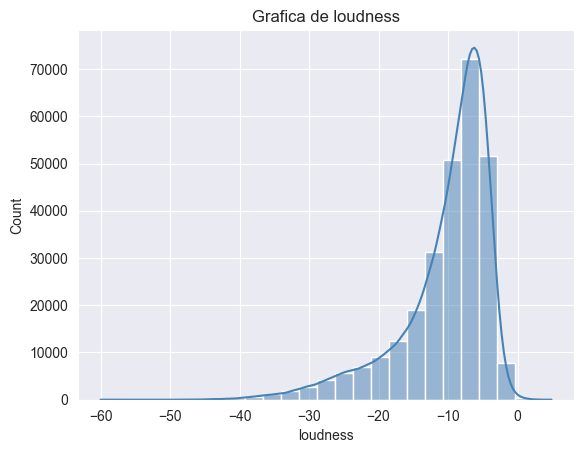

In [8]:
sns.histplot(datos, x='loudness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de loudness')

La variable *loudness* en Spotify presenta una distribución sesgada a la derecha, lo que indica que la mayoría de las canciones tienen un nivel de volumen moderado, sin alcanzar valores extremos. Sin
embargo, la cola derecha de la distribución revela la presencia de un pequeño número de canciones con niveles de volumen cercanos a 0 dB, asociadas principalmente a géneros como el rock, el metal y otros
estilos con alta intensidad sonora. Por otro lado, la cola izquierda —de mayor extensión— refleja la predominancia de géneros más relajados, cuya característica distintiva es un volumen bajo o moderado.
Este patrón resalta la diversidad en los niveles de *loudness* dentro del catálogo musical, evidenciando que, aunque la mayoría de las canciones se ubica en un rango intermedio, existen variaciones
significativas entre géneros que pueden ser aprovechadas en análisis de segmentación, los cuales se abordaran mas adelante

### Comparacion de variables 
A continuan se observaran las relaciones entre las distintas variables para conocer is existen correlaciones importantes entre ellas


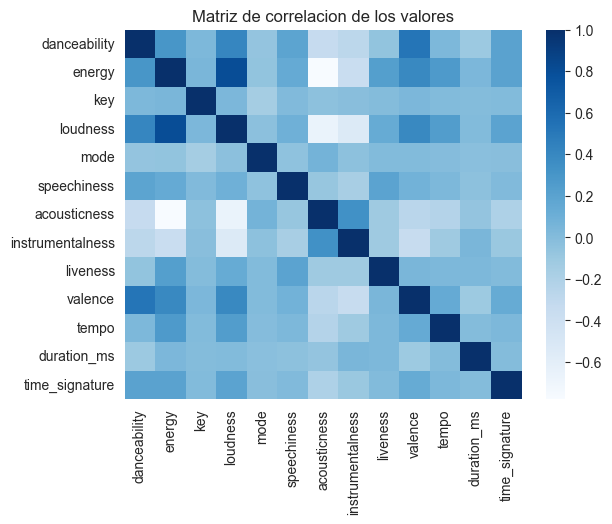

--- Top 5 Correlaciones Positivas ---
loudness  energy          0.802642
valence   danceability    0.521399
loudness  danceability    0.414604
valence   loudness        0.392798
          energy          0.391237
dtype: float64

--- Top 5 Correlaciones Negativas ---
acousticness      energy             -0.779596
                  loudness           -0.663215
instrumentalness  loudness           -0.541662
                  energy             -0.361357
valence           instrumentalness   -0.345532
dtype: float64


In [19]:
def top_correlaciones(datos, n=5):
    matriz_corr = datos.corr(numeric_only=True)
    
    sns.heatmap(matriz_corr, cmap='Blues')
    plt.title('Matriz de correlacion de los valores')
    plt.show()    

    matriz_sin_diag = matriz_corr.where(~np.tril(np.ones(matriz_corr.shape)).astype(bool))
    corr_pairs = matriz_sin_diag.unstack().dropna()
    
    top_positivas = corr_pairs.nlargest(n)
    top_negativas = corr_pairs.nsmallest(n)
    
    return top_positivas, top_negativas

fuertes_positivas, fuertes_negativas = top_correlaciones(datos, n=5)

print("--- Top 5 Correlaciones Positivas ---")
print(fuertes_positivas)
print("\n--- Top 5 Correlaciones Negativas ---")
print(fuertes_negativas)


#### Conclusiones de correlaciones
Despues de obtener las relaciones mas fuertes tanto positivas como negativas, podemos decir lo siguiente.

* loudness - energy)